In [1]:
import os
os.makedirs("degraded/blur_sigma1", exist_ok=True)
os.makedirs("degraded/blur_sigma2", exist_ok=True)
os.makedirs("degraded/blur_sigma3", exist_ok=True)

print("Folders created:")
print("degraded/blur_sigma1/")
print("degraded/blur_sigma2/")
print("degraded/blur_sigma3/")

Folders created:
degraded/blur_sigma1/
degraded/blur_sigma2/
degraded/blur_sigma3/


### Gaussian Blur

In [4]:
import cv2
cap = cv2.VideoCapture("data/phone_walk.mp4")

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    blur1 = cv2.GaussianBlur(frame, (0, 0), sigmaX=1)
    blur2 = cv2.GaussianBlur(frame, (0, 0), sigmaX=2)
    blur3 = cv2.GaussianBlur(frame, (0, 0), sigmaX=3)

    cv2.imwrite(f"degraded/blur_sigma1/frame_{frame_count:04d}.jpg", blur1)
    cv2.imwrite(f"degraded/blur_sigma2/frame_{frame_count:04d}.jpg", blur2)
    cv2.imwrite(f"degraded/blur_sigma3/frame_{frame_count:04d}.jpg", blur3)

    frame_count += 1

cap.release()
print("Gaussian blur complete")
print("Frames saved per sigma level:", frame_count)
print("Total images saved:", frame_count*3)

Gaussian blur complete
Frames saved per sigma level: 367
Total images saved: 1101


In [6]:
import os
os.makedirs("degraded/jpeg_q90", exist_ok=True)
os.makedirs("degraded/jpeg_q70", exist_ok=True)
os.makedirs("degraded/jpeg_q50", exist_ok=True)

print("Folders created")
print("degraded/jpeg_q90/")
print("degraded/jpeg_q70/")
print("degraded/jpeg_q50/")

Folders created
degraded/jpeg_q90/
degraded/jpeg_q70/
degraded/jpeg_q50/


In [10]:
import cv2

cap = cv2.VideoCapture("data/phone_walk.mp4")

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    encode_param_90 = [cv2.IMWRITE_JPEG_QUALITY, 90]
    _, compressed_90 = cv2.imencode(".jpg", frame, encode_param_90)
    frame_q90 = cv2.imdecode(compressed_90, cv2.IMREAD_COLOR)

    encode_param_70 = [cv2.IMWRITE_JPEG_QUALITY, 70]
    _, compressed_70 = cv2.imencode(".jpg", frame, encode_param_70)
    frame_q70 = cv2.imdecode(compressed_70, cv2.IMREAD_COLOR)

    encode_param_50 = [cv2.IMWRITE_JPEG_QUALITY, 50]
    _, compressed_50 = cv2.imencode(".jpg", frame, encode_param_50)
    frame_q50 = cv2.imdecode(compressed_50, cv2.IMREAD_COLOR)

    cv2.imwrite(f"degraded/jpeg_q90/frame_{frame_count:04d}.jpg", frame_q90)
    cv2.imwrite(f"degraded/jpeg_q70/frame_{frame_count:04d}.jpg", frame_q70)
    cv2.imwrite(f"degraded/jpeg_q50/frame_{frame_count:04d}.jpg", frame_q50)

    frame_count += 1

cap.release()

print("JPEG compression complete")
print("Frames saved quality level:", frame_count)
print("Total images saved:", frame_count * 3)
            
    

JPEG compression complete
Frames saved quality level: 367
Total images saved: 1101


In [11]:
import os

os.makedirs("degraded/gaussian_noise", exist_ok=True)
print("Folder created: degraded/gaussian_noise/")


Folder created: degraded/gaussian_noise/


In [12]:
import cv2
import numpy as np

cap = cv2.VideoCapture("data/phone_walk.mp4")

frame_count = 0 

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_float = frame.astype(np.float32)
    noise = np.random.normal(0, 25, frame.shape).astype(np.float32)

    noisy_frame = frame_float + noise
    noisy_frame = np.clip(noisy_frame, 0, 255)
    noisy_frame = noisy_frame.astype(np.uint8)

    cv2.imwrite(f"degraded/gaussian_noise/frame_{frame_count:04d}.jpg", noisy_frame)

    frame_count += 1

cap.release()

print("Gaussian noise complete")
print("Frames saved:", frame_count)

Gaussian noise complete
Frames saved: 367


In [15]:
import os
import cv2
import matplotlib.pyplot as plt

folders = [
    "degraded/blur_sigma1",
    "degraded/blur_sigma2",
    "degraded/blur_sigma3",
    "degraded/jpeg_q90",
    "degraded/jpeg_q70",
    "degraded/jpeg_q50",
    "degraded/gaussian_noise"
]

print("Verification - File counts per condition:")
print("-----------------------------------------")
all_good = True
for folder in folders:
    files = os.listdir(folder)
    count = len(files)
    status = "ok" if count == 367 else "ERROR - expected 367"
    if count != 367:
        all_good = False
    print(f"{folder:<30} {count} frames {status}")

print()
if all_good:
    print("All folders correct - 367 frames in every condition")
else:
    print("some folders have wrong counts - check above")

print()
print("Total degraded images:", 367*7)


Verification - File counts per condition:
-----------------------------------------
degraded/blur_sigma1           367 frames ok
degraded/blur_sigma2           367 frames ok
degraded/blur_sigma3           367 frames ok
degraded/jpeg_q90              367 frames ok
degraded/jpeg_q70              367 frames ok
degraded/jpeg_q50              367 frames ok
degraded/gaussian_noise        367 frames ok

All folders correct - 367 frames in every condition

Total degraded images: 2569


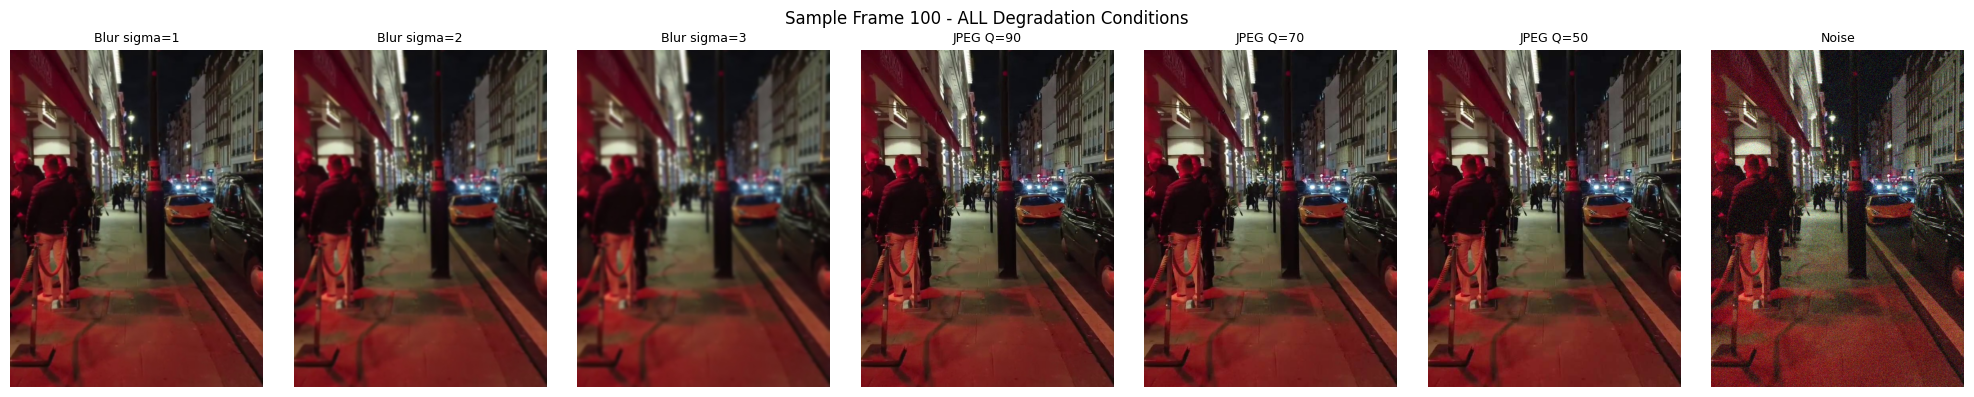

Saved: outputs/degradation_samples.jpg


In [19]:
sample_frame = "frame_0100.jpg"
fig, axes = plt.subplots(1, 7, figsize=(20,4))

titles = ["Blur sigma=1", "Blur sigma=2", "Blur sigma=3", "JPEG Q=90", "JPEG Q=70", "JPEG Q=50", "Noise" ]
for i, (folder, title) in enumerate(zip(folders, titles)):
    img_path = os.path.join(folder, sample_frame)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(title, fontsize=9)
    axes[i].axis("off")

plt.suptitle("Sample Frame 100 - ALL Degradation Conditions", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/degradation_samples.jpg", dpi=150)
plt.show()
print("Saved: outputs/degradation_samples.jpg")

                        
